# Baseline Training - Hopper-v5

Hopper is a one-legged locomotion task where early falls are common. The baseline pass tracks return and termination rate to understand stability under a short budget.

The full baseline training path is kept in this notebook. Saved CSV outputs are
reused by default, so rerunning the notebook does not retrain the 250k-step
baseline runs unless `RUN_TRAINING=True`.


## Load baseline paths

Define the shared folder layout used by the baseline notebooks.


In [1]:
from pathlib import Path
import os, sys, time

def find_baseline_root():
    start = Path.cwd().resolve()
    for base in [start, *start.parents]:
        for candidate in [base, base / "baseline", base / "MuJoCo_RL_Project_Final_Submission" / "baseline"]:
            if (candidate / "baseline_summary.md").exists() and (candidate / "results").exists():
                return candidate.resolve()
    raise RuntimeError("Could not locate baseline folder")

BASE_DIR = find_baseline_root()
os.chdir(BASE_DIR)
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

RAW_DIR = BASE_DIR / "results" / "raw"
PROC_DIR = BASE_DIR / "results" / "processed"
FINAL_DIR = BASE_DIR / "results" / "final"
FIG_DIR = BASE_DIR / "figures"
REPORT_FIG_DIR = FIG_DIR / "report_ready"
for folder in [RAW_DIR, PROC_DIR, FINAL_DIR, REPORT_FIG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

ENV_IDS = ["HalfCheetah-v5", "Hopper-v5", "Walker2d-v5"]
ALGORITHMS = ["PPO", "SAC", "TD3", "DDPG", "TQC"]
print(f"Baseline root: {BASE_DIR}")
print(f"Python: {sys.executable}")


Baseline root: D:\MuJoCo_RL_Project\MuJoCo_RL_Project_Final_Submission\baseline
Python: C:\Users\digilians01\.conda\envs\RL_PROJECT\python.exe


## Training configuration

The baseline pass used five algorithms, five seeds, and a 250k-step budget.


In [2]:
ENV_ID = "Hopper-v5"


In [3]:
import gymnasium as gym
import torch
from stable_baselines3 import PPO, SAC, TD3, DDPG
from sb3_contrib import TQC
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_util import make_vec_env

ALGO_CLASSES = {"PPO": PPO, "SAC": SAC, "TD3": TD3, "DDPG": DDPG, "TQC": TQC}
TOTAL_TIMESTEPS = 250_000
EVAL_FREQ = 12_500
N_EVAL_EPISODES = 10
SEEDS = list(range(5))
RUN_TRAINING = False
FORCE_RERUN = False
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODELS_DIR = BASE_DIR / "models" / ENV_ID
print(f"Environment: {ENV_ID}")
print(f"Device: {DEVICE}")
print(f"RUN_TRAINING: {RUN_TRAINING}")


Environment: Hopper-v5
Device: cuda
RUN_TRAINING: False


## Run plan

Each row is one algorithm/seed training job.


In [4]:
def make_run_id(env_id, algo, seed, timesteps):
    return f"{env_id}__{algo}__seed{seed:02d}__steps{timesteps}"

rows = []
for algo in ALGORITHMS:
    for seed in SEEDS:
        run_id = make_run_id(ENV_ID, algo, seed, TOTAL_TIMESTEPS)
        rows.append({
            "run_id": run_id,
            "environment": ENV_ID,
            "algorithm": algo,
            "seed": seed,
            "total_timesteps": TOTAL_TIMESTEPS,
            "model_path": str(MODELS_DIR / f"{run_id}.zip"),
        })
plan_df = pd.DataFrame(rows)
eval_path = RAW_DIR / f"{ENV_ID}_eval_log.csv"
final_path = RAW_DIR / f"{ENV_ID}_final_eval.csv"
meta_path = RAW_DIR / f"{ENV_ID}_run_metadata.csv"
existing_final = pd.read_csv(final_path) if final_path.exists() else pd.DataFrame()
completed = set(existing_final["run_id"]) if not existing_final.empty else set()
plan_df["state"] = plan_df["run_id"].map(lambda r: "results_available" if r in completed else "missing")
display(plan_df.groupby(["algorithm", "state"]).size().unstack(fill_value=0))
print(f"Planned runs: {len(plan_df)}")


state,results_available
algorithm,
DDPG,5
PPO,5
SAC,5
TD3,5
TQC,5


Planned runs: 25


## Periodic evaluation callback

The callback stores evaluation returns during training.


In [5]:
def evaluate_episodes(model, env_id, n_episodes, seed_base):
    env = gym.make(env_id)
    records = []
    for ep in range(n_episodes):
        obs, info = env.reset(seed=seed_base + ep)
        total_reward, steps = 0.0, 0
        terminated, truncated = False, False
        while not (terminated or truncated):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += float(reward)
            steps += 1
        records.append({
            "eval_episode": ep, "eval_return": total_reward,
            "eval_episode_length": steps, "terminated": terminated,
            "truncated": truncated,
        })
    env.close()
    return records

class PeriodicEvalCallback(BaseCallback):
    def __init__(self, env_id, eval_freq, n_eval_episodes, seed, verbose=0):
        super().__init__(verbose)
        self.env_id = env_id
        self.eval_freq = eval_freq
        self.n_eval_episodes = n_eval_episodes
        self.seed = seed
        self.records = []
        self.last_eval_step = -1

    def _on_step(self):
        eval_step = (self.num_timesteps // self.eval_freq) * self.eval_freq
        if eval_step > self.last_eval_step and eval_step > 0:
            self.last_eval_step = eval_step
            rows = evaluate_episodes(self.model, self.env_id, self.n_eval_episodes, self.seed * 1000)
            for row in rows:
                row["eval_timestep"] = eval_step
            self.records.extend(rows)
        return True

    def to_frame(self):
        return pd.DataFrame(self.records)


## Training helper

This helper builds the model, trains it, saves it, and summarizes final evaluation.


In [6]:
def summarize_final(run, eval_df, wall_clock):
    last_step = eval_df["eval_timestep"].max()
    final_data = eval_df[eval_df["eval_timestep"] == last_step]
    returns = final_data["eval_return"]
    row = run[["run_id", "environment", "algorithm", "seed", "total_timesteps"]].to_dict()
    row.update({
        "mean_return": returns.mean(),
        "std_return": returns.std(),
        "median_return": returns.median(),
        "min_return": returns.min(),
        "max_return": returns.max(),
        "mean_episode_length": final_data["eval_episode_length"].mean(),
        "termination_rate": final_data.get("terminated", pd.Series(dtype=float)).mean(),
        "truncation_rate": final_data.get("truncated", pd.Series(dtype=float)).mean(),
        "wall_clock_seconds": round(wall_clock, 2),
    })
    return row

def train_one(run):
    if run["state"] == "results_available" and not FORCE_RERUN:
        return {"run_id": run["run_id"], "status": "results_available"}
    if not RUN_TRAINING:
        return {"run_id": run["run_id"], "status": "training_disabled"}
    env = make_vec_env(ENV_ID, n_envs=max(1, os.cpu_count() or 1), seed=int(run["seed"]))
    model = ALGO_CLASSES[run["algorithm"]]("MlpPolicy", env, seed=int(run["seed"]), verbose=0, device=DEVICE)
    eval_cb = PeriodicEvalCallback(ENV_ID, EVAL_FREQ, N_EVAL_EPISODES, int(run["seed"]))
    start = time.time()
    model.learn(total_timesteps=int(run["total_timesteps"]), callback=eval_cb)
    wall_clock = time.time() - start
    Path(run["model_path"]).parent.mkdir(parents=True, exist_ok=True)
    model.save(run["model_path"])
    eval_df = eval_cb.to_frame()
    env.close()
    return {"run_id": run["run_id"], "status": "trained", "eval_df": eval_df, "wall_clock": wall_clock}


## Execute or reuse results

Existing CSV results are reused unless training is explicitly enabled.


In [7]:
run_results = [train_one(row) for _, row in plan_df.iterrows()]
status_rows = [{k: v for k, v in r.items() if k not in {"eval_df", "wall_clock"}} for r in run_results]
status_df = pd.DataFrame(status_rows)
display(status_df["status"].value_counts().rename_axis("status").reset_index(name="count"))

new_eval_frames, new_final_rows = [], []
for result in run_results:
    if result.get("status") != "trained":
        continue
    run = plan_df[plan_df["run_id"] == result["run_id"]].iloc[0]
    eval_df = result["eval_df"].copy()
    for col in ["run_id", "environment", "algorithm", "seed"]:
        eval_df[col] = run[col]
    new_eval_frames.append(eval_df)
    new_final_rows.append(summarize_final(run, eval_df, result["wall_clock"]))

if new_eval_frames:
    pd.concat(new_eval_frames, ignore_index=True).to_csv(eval_path, index=False)
    pd.DataFrame(new_final_rows).to_csv(final_path, index=False)
    print("Saved new baseline training outputs.")
else:
    print("No new training was run in this execution.")


,status,count
0,results_available,25


No new training was run in this execution.


## Result summary

Load the baseline CSV outputs and summarize this environment.


In [8]:
eval_log = pd.read_csv(eval_path) if eval_path.exists() else pd.DataFrame()
final_eval = pd.read_csv(final_path) if final_path.exists() else pd.DataFrame()
metadata = pd.read_csv(meta_path) if meta_path.exists() else pd.DataFrame()
print(f"Eval log rows: {len(eval_log)}")
print(f"Final eval rows: {len(final_eval)}")
if not final_eval.empty:
    summary = (final_eval.groupby("algorithm")
               .agg(runs=("run_id", "nunique"), mean_return=("mean_return", "mean"),
                    std_return=("mean_return", "std"), mean_ep_len=("mean_episode_length", "mean"))
               .reset_index())
    display(summary.round(3))


Eval log rows: 5100
Final eval rows: 25


,algorithm,runs,mean_return,std_return,mean_ep_len
0,DDPG,5,221.954,144.988,101.54
1,PPO,5,223.397,11.680,101.14
2,SAC,5,406.908,205.778,151.18
3,TD3,5,139.143,124.029,67.90
4,TQC,5,318.568,33.940,133.34


## Learning curve check

A compact view of the baseline learning curves.


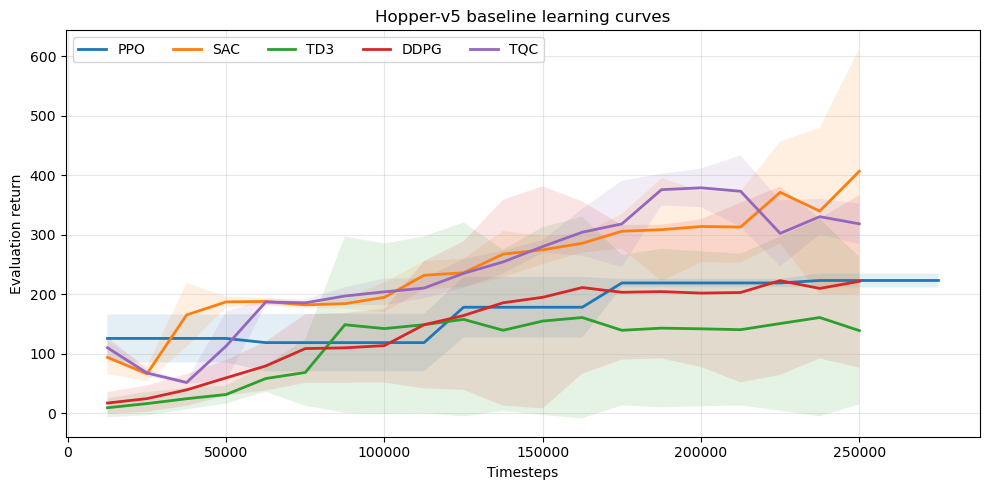

In [9]:
if not eval_log.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    for algo in ALGORITHMS:
        part = eval_log[eval_log["algorithm"] == algo]
        if part.empty:
            continue
        curve = (part.groupby(["seed", "eval_timestep"])["eval_return"].mean()
                 .reset_index().groupby("eval_timestep")["eval_return"]
                 .agg(["mean", "std"]).reset_index())
        ax.plot(curve["eval_timestep"], curve["mean"], label=algo, linewidth=2)
        ax.fill_between(curve["eval_timestep"], curve["mean"] - curve["std"],
                        curve["mean"] + curve["std"], alpha=0.12)
    ax.set_title(f"{ENV_ID} baseline learning curves")
    ax.set_xlabel("Timesteps")
    ax.set_ylabel("Evaluation return")
    ax.grid(alpha=0.3)
    ax.legend(ncol=5)
    plt.tight_layout()
    plt.show()
